In [1]:
!pip install segmentation-models-pytorch albumentations torchmetrics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 108.3 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.


In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchmetrics
import matplotlib.pyplot as plt
from pathlib import Path

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [4]:
base_path = Path('/kaggle/input/deepglobe-road-extraction-dataset')

# List contents
for split in ['train', 'valid', 'test']:
    split_path = base_path / split
    if split_path.exists():
        files = list(split_path.glob('*_sat.jpg'))
        print(f"{split}: {len(files)} images")

In [5]:
class DeepGlobeDataset(Dataset):
    def __init__(self, img_dir, transform=None, subset_size=None):
        self.img_dir = Path(img_dir)
        self.transform = transform
        
        # Get all satellite images
        self.images = sorted(self.img_dir.glob('*_sat.jpg'))
        
        # Use subset for faster training
        if subset_size:
            self.images = self.images[:subset_size]
            
        print(f"Dataset size: {len(self.images)}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.images[idx]
        mask_path = str(img_path).replace('_sat.jpg', '_mask.png')
        
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        # Binarize mask — white = road
        mask = (mask > 127).astype(np.float32)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        return image, mask.unsqueeze(0)

In [18]:
# Training augmentations
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.CoarseDropout(
        num_holes_range=(3, 8),
        hole_height_range=(32, 64),
        hole_width_range=(32, 64),
        fill=0, p=0.4
    ),
    A.RandomShadow(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

# Both from train folder — manual split
base_path = '/kaggle/input/datasets/balraj98/deepglobe-road-extraction-dataset'
train_dir = f'{base_path}/train'

# Create full dataset first to split
full_dataset = DeepGlobeDataset(train_dir, transform=None, subset_size=350)
all_images = full_dataset.images

# 300 train, 50 val
train_images = all_images[:300]
val_images = all_images[300:350]

# Create separate datasets with correct transforms
class DeepGlobeSubset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.images = image_paths
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = str(img_path).replace('_sat.jpg', '_mask.png')
        
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        return image, mask.unsqueeze(0)

train_dataset = DeepGlobeSubset(train_images, train_transform)
val_dataset = DeepGlobeSubset(val_images, val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Dataset size: 350
Train size: 300
Val size: 50
Train batches: 38
Val batches: 7


In [19]:
# UNet++ with ResNet-34 backbone
model = smp.UnetPlusPlus(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None  # raw logits, we apply sigmoid in loss
)

model = model.to(device)
print("Model loaded: UNet++ / ResNet-34")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded: UNet++ / ResNet-34
Parameters: 26,078,609


In [23]:
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.4, beta=0.3, gamma=0.3):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        
        self.dice_loss = smp.losses.DiceLoss(mode='binary')
        self.iou_loss = smp.losses.JaccardLoss(mode='binary')
        self.bce_loss = nn.BCEWithLogitsLoss()
    
    def boundary_loss(self, pred, target):
        pred_sigmoid = torch.sigmoid(pred)
        kernel = torch.ones(1, 1, 3, 3, device=pred.device) / 9.0
        smoothed = nn.functional.conv2d(
            target, kernel, padding=1
        )
        boundary = (smoothed > 0) & (smoothed < 1)
        boundary = boundary.float()
        
        if boundary.sum() < 1:
            return torch.tensor(0.0, device=pred.device)
        
        boundary_pred = pred_sigmoid * boundary
        boundary_target = target * boundary
        loss = nn.functional.mse_loss(boundary_pred, boundary_target)
        return loss
    
    def forward(self, pred, target):
        dice = self.dice_loss(pred, target)
        iou = self.iou_loss(pred, target)
        boundary = self.boundary_loss(pred, target)
        
        total = (self.alpha * dice + 
                 self.beta * iou + 
                 self.gamma * boundary)
        return total, dice, iou, boundary

criterion = CombinedLoss(alpha=0.4, beta=0.3, gamma=0.3)

In [24]:
# Metrics
iou_metric = torchmetrics.JaccardIndex(task='binary', threshold=0.5).to(device)
f1_metric = torchmetrics.F1Score(task='binary', threshold=0.5).to(device)

# Optimizer + scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20, eta_min=1e-5
)

In [25]:
EPOCHS = 20
best_iou = 0
train_losses, val_ious = [], []

for epoch in range(EPOCHS):
    # Training
    model.train()
    epoch_loss = 0
    
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss, dice, iou, boundary = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    iou_metric.reset()
    f1_metric.reset()
    
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = torch.sigmoid(model(images))
            masks_int = masks.long()
            iou_metric.update(outputs, masks_int)
            f1_metric.update(outputs, masks_int)
    
    val_iou = iou_metric.compute().item()
    val_f1 = f1_metric.compute().item()
    val_ious.append(val_iou)
    
    scheduler.step()
    
    # Save best model
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), 'terrain_best_model.pth')
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {avg_train_loss:.4f} | "
          f"Val IoU: {val_iou:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"Best IoU: {best_iou:.4f}")

Epoch 01/20 | Loss: 0.4136 | Val IoU: 0.3596 | Val F1: 0.5290 | Best IoU: 0.3596
Epoch 02/20 | Loss: 0.3866 | Val IoU: 0.4294 | Val F1: 0.6008 | Best IoU: 0.4294
Epoch 03/20 | Loss: 0.3720 | Val IoU: 0.4144 | Val F1: 0.5859 | Best IoU: 0.4294
Epoch 04/20 | Loss: 0.3663 | Val IoU: 0.4370 | Val F1: 0.6082 | Best IoU: 0.4370
Epoch 05/20 | Loss: 0.3527 | Val IoU: 0.4685 | Val F1: 0.6381 | Best IoU: 0.4685
Epoch 06/20 | Loss: 0.3376 | Val IoU: 0.4886 | Val F1: 0.6565 | Best IoU: 0.4886
Epoch 07/20 | Loss: 0.3488 | Val IoU: 0.4187 | Val F1: 0.5902 | Best IoU: 0.4886
Epoch 08/20 | Loss: 0.3366 | Val IoU: 0.4733 | Val F1: 0.6425 | Best IoU: 0.4886
Epoch 09/20 | Loss: 0.3249 | Val IoU: 0.4917 | Val F1: 0.6592 | Best IoU: 0.4917
Epoch 10/20 | Loss: 0.3212 | Val IoU: 0.4860 | Val F1: 0.6541 | Best IoU: 0.4917
Epoch 11/20 | Loss: 0.3065 | Val IoU: 0.5093 | Val F1: 0.6749 | Best IoU: 0.5093
Epoch 12/20 | Loss: 0.3054 | Val IoU: 0.5268 | Val F1: 0.6901 | Best IoU: 0.5268
Epoch 13/20 | Loss: 0.2988 |

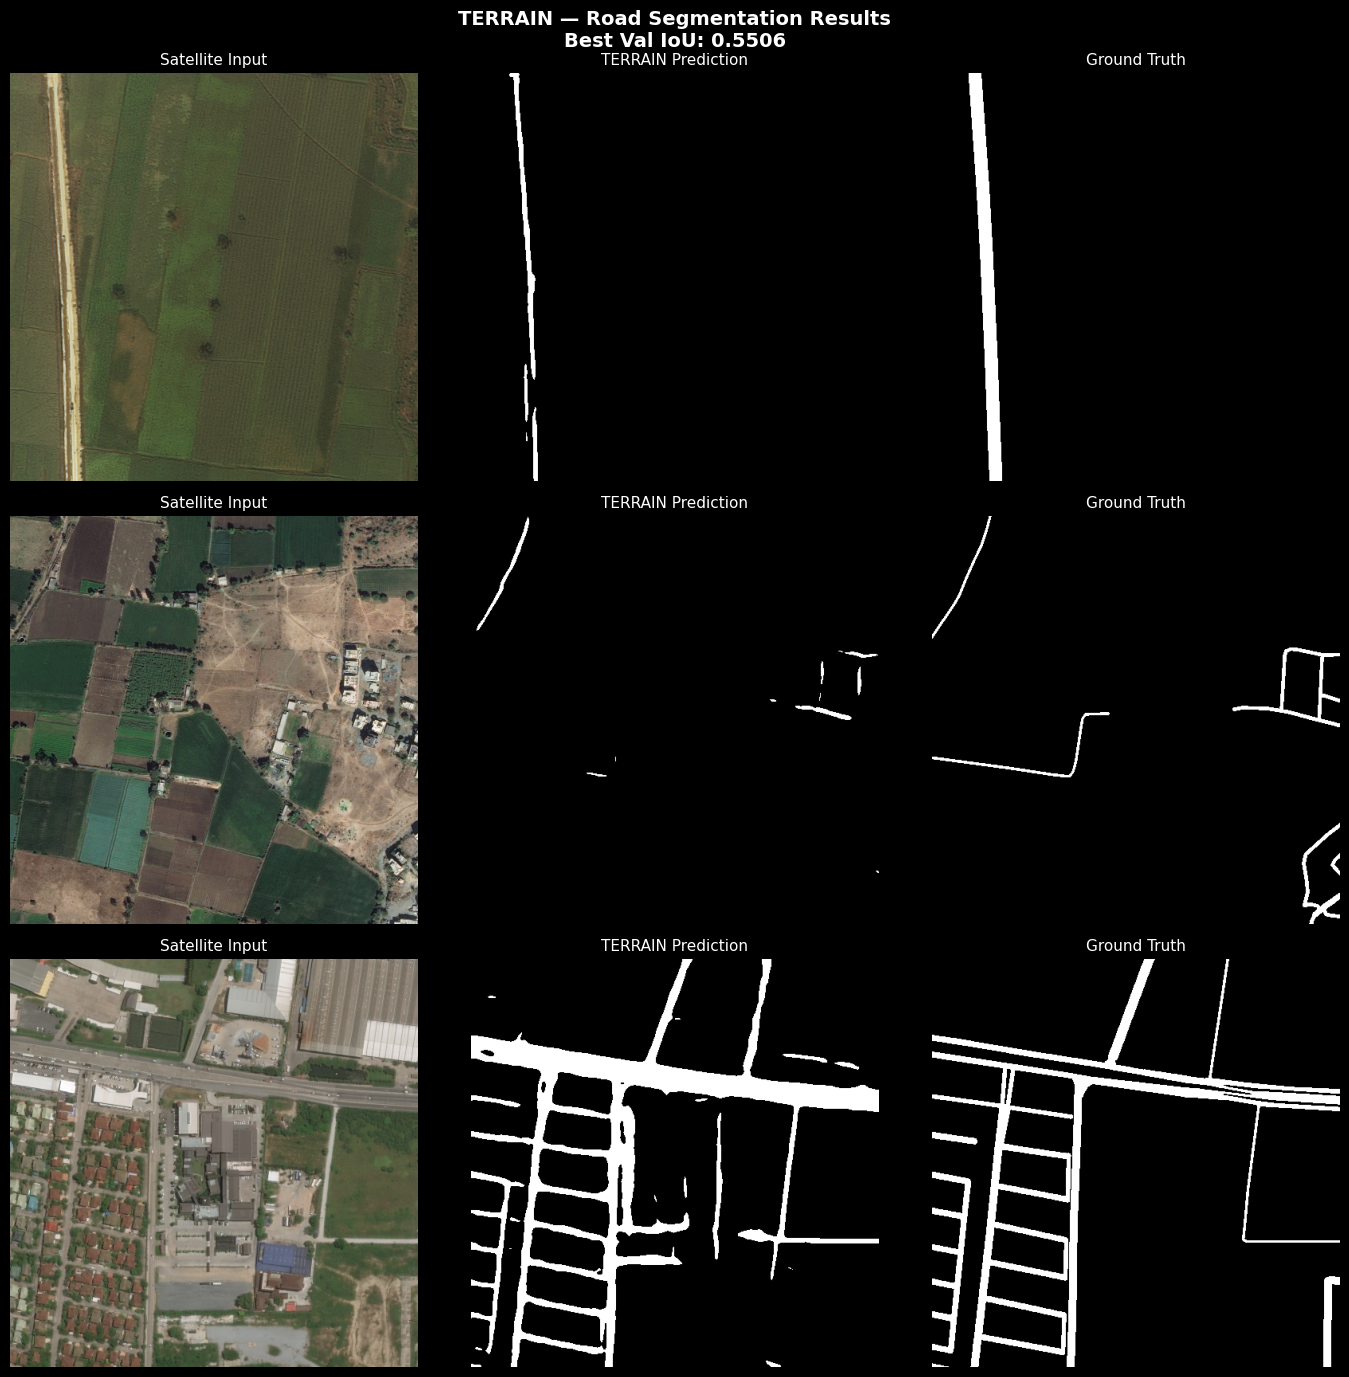


Final Best IoU: 0.5506


In [26]:
# Load best model
model.load_state_dict(torch.load('terrain_best_model.pth'))
model.eval()

# Get a batch from validation
images, masks = next(iter(val_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    outputs = torch.sigmoid(model(images))
    predictions = (outputs > 0.5).float()

# Plot 3 examples
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.patch.set_facecolor('black')

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

for i in range(3):
    # Denormalize image
    img = images[i].cpu() * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    
    gt_mask = masks[i, 0].cpu().numpy()
    pred_mask = predictions[i, 0].cpu().numpy()
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Satellite Input', color='white', fontsize=11)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(pred_mask, cmap='gray')
    axes[i, 1].set_title('TERRAIN Prediction', color='white', fontsize=11)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(gt_mask, cmap='gray')
    axes[i, 2].set_title('Ground Truth', color='white', fontsize=11)
    axes[i, 2].axis('off')

plt.suptitle(f'TERRAIN — Road Segmentation Results\nBest Val IoU: {best_iou:.4f}',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('terrain_segmentation_results.png', dpi=200,
            bbox_inches='tight', facecolor='black')
plt.show()
print(f"\nFinal Best IoU: {best_iou:.4f}")

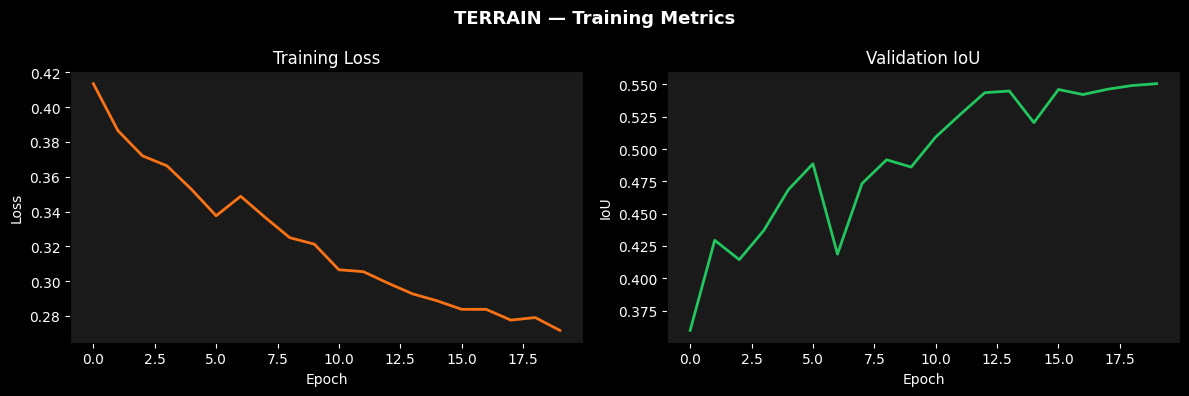

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), facecolor='black')

ax[0].plot(train_losses, color='#F97316', linewidth=2)
ax[0].set_title('Training Loss', color='white')
ax[0].set_xlabel('Epoch', color='white')
ax[0].set_ylabel('Loss', color='white')
ax[0].tick_params(colors='white')
ax[0].set_facecolor('#1a1a1a')

ax[1].plot(val_ious, color='#22C55E', linewidth=2)
ax[1].set_title('Validation IoU', color='white')
ax[1].set_xlabel('Epoch', color='white')
ax[1].set_ylabel('IoU', color='white')
ax[1].tick_params(colors='white')
ax[1].set_facecolor('#1a1a1a')

plt.suptitle('TERRAIN — Training Metrics', color='white',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('terrain_training_curve.png', dpi=200,
            bbox_inches='tight', facecolor='black')
plt.show()